# 08 — From chains to video: buying time by cutting space

The first seven notebooks live on a 1-D chain, where exact belief propagation is available
because the graph is a line. Real signals are not lines. This notebook is about what happens
when you push the same machinery onto images and then onto video, and hit the constraint that
makes the whole approach interesting: **exact BP needs a loop-free graph, and the world is not
loop-free.**

A wavelet hidden Markov *tree* handles a single image — parent coefficient to child
coefficients, no loops, exact inference. Add a second frame and the natural model wants both
spatial edges (within a frame) *and* temporal edges (between frames). Together they close
loops, and exactness is gone.

So there is a budget. Every temporal edge has to be paid for by severing a spatial one. This
notebook measures the exchange rate — and finds that the two things you would want to optimise
disagree about where the optimum is.

## The cut

`cut_depth` parameterises the trade. At depth $d$, the spatial tree is severed at level $d$,
splitting each orientation into independent components; the freed budget goes to temporal edges
linking corresponding coefficients across frames.

| `cut_depth` | components per orientation | spatial edges severed per frame |
|---|---|---|
| 0 | 1 (whole tree intact) | 0 — a "caterpillar": one temporal spine, no cuts |
| 1 | 5 | 12 |
| 2 | 17 | 48 |
| 3 | 65 | 192 |
| 4 | 257 | 768 |

Depth 0 is the pure caterpillar: spatial tree fully intact, temporal coupling only at the root.
Depth 4 has shredded the spatial structure into 257 pieces per orientation to afford dense
temporal coupling. Somewhere in between is the right answer — if there is one.

Two things get measured at each depth:

- **Held-out log-likelihood per sequence** — does the model explain unseen video better?
- **Generated frame-difference energy** — do the *samples* move like the data? The reference
  sequences sit at $0.211$; independent frames would give $2.0$. Lower is more temporally
  coherent, and $0.211$ is the target.

> **What "video" means here.** No video dataset is involved. `src/video_data.py` builds
> sequences by reflect-padding a CIFAR image and cropping a translating $32\times32$ window —
> its own docstring calls this *"real natural-image statistics with synthetic rigid motion"*
> and notes that real video has non-rigid motion, occlusion and lighting change, none of which
> this has. Everything below is measured against those reference sequences, and "real" in the
> tables means *the reference sequences*, not video. `IMAGE_EXTENSION_STAGE1.md` lists real
> video data under **What remains**.

In [1]:
import sys, csv, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
ROOT = "../outputs/exp_26_video"

cut = list(csv.DictReader(open(os.path.join(ROOT, "cutcurve.csv"))))
fit = list(csv.DictReader(open(os.path.join(ROOT, "fit.csv"))))
coh = list(csv.DictReader(open(os.path.join(ROOT, "coherence.csv"))))

f = lambda r, k: float(r[k])
depths = [int(f(r, "cut_depth")) for r in cut]
loglik = [f(r, "heldout_loglik_per_sequence") for r in cut]
gen_e  = [f(r, "frame_diff_energy_generated") for r in cut]
real_e = f(cut[0], "frame_diff_energy_real")
sev    = [int(f(r, "spatial_edges_severed_per_frame")) for r in cut]
comps  = [int(f(r, "components_per_orientation")) for r in cut]

print(f"reference-sequence frame-difference energy (the target): {real_e:.4f}")
print(f"independent frames would give:                   2.0\n")
print(f"{'cut':>4} {'comps':>7} {'severed':>8} {'heldout loglik':>16} {'gen frame-diff':>16} {'x ref':>8}")
print("-" * 64)
for i, d in enumerate(depths):
    print(f"{d:>4} {comps[i]:>7} {sev[i]:>8} {loglik[i]:>16.1f} {gen_e[i]:>16.4f} "
          f"{gen_e[i]/real_e:>7.2f}x")

# every EM fit in this sweep must be monotone; a violation would invalidate the comparison
viol = [f(r, "monotone_violation") for r in cut]
print(f"\nEM monotonicity violations across all five fits: {sum(viol):.0f}")

reference-sequence frame-difference energy (the target): 0.2107
independent frames would give:                   2.0

 cut   comps  severed   heldout loglik   gen frame-diff    x ref
----------------------------------------------------------------
   0       1        0          -5902.5           1.0617    5.04x
   1       5       12          -5815.7           0.6796    3.23x
   2      17       48          -5796.1           0.7845    3.72x
   3      65      192          -5892.1           0.8840    4.20x
   4     257      768          -5921.6           1.0059    4.77x

EM monotonicity violations across all five fits: 0


## Result 1 — the likelihood curve turns over

This is the finding. Held-out likelihood is **not** monotone in the cut depth: it improves as
spatial edges are traded for temporal ones, peaks, and then degrades as the spatial tree is
shredded past usefulness.

That the curve turns over at all is the point. It says the trade is real in both directions —
there is genuine information in the temporal edges that the intact tree cannot access, and
genuine information in the spatial tree that dense temporal coupling cannot replace.

best held-out likelihood : cut_depth=2  (-5796.1, +106.4 nats vs the caterpillar)
best temporal coherence  : cut_depth=1  (0.6796 = 3.23x the reference)

  These are DIFFERENT cut depths (2 vs 1).
  The two axes do not agree about the optimum, so 'the best model' is not
  well defined without saying which quantity you are optimising.


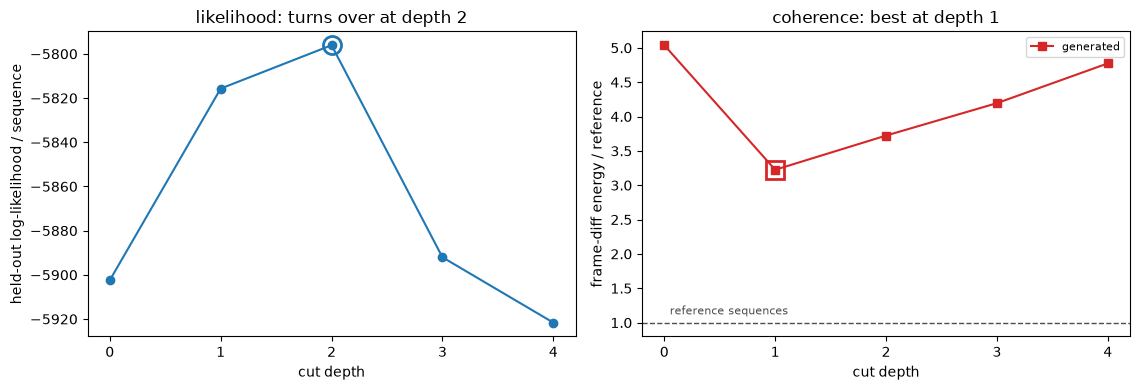

In [2]:
best_ll = int(np.argmax(loglik))
best_co = int(np.argmin(gen_e))

print(f"best held-out likelihood : cut_depth={depths[best_ll]}  "
      f"({loglik[best_ll]:.1f}, {loglik[best_ll]-loglik[0]:+.1f} nats vs the caterpillar)")
print(f"best temporal coherence  : cut_depth={depths[best_co]}  "
      f"({gen_e[best_co]:.4f} = {gen_e[best_co]/real_e:.2f}x the reference)")
print()
if best_ll != best_co:
    print(f"  These are DIFFERENT cut depths ({depths[best_ll]} vs {depths[best_co]}).")
    print("  The two axes do not agree about the optimum, so 'the best model' is not")
    print("  well defined without saying which quantity you are optimising.")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

ax[0].plot(depths, loglik, "C0-o", ms=6)
ax[0].plot(depths[best_ll], loglik[best_ll], "o", ms=13, mfc="none", mec="C0", mew=2)
ax[0].set_xlabel("cut depth"); ax[0].set_ylabel("held-out log-likelihood / sequence")
ax[0].set_title("likelihood: turns over at depth 2"); ax[0].set_xticks(depths)

ax[1].plot(depths, [e / real_e for e in gen_e], "C3-s", ms=6, label="generated")
ax[1].plot(depths[best_co], gen_e[best_co] / real_e, "s", ms=13, mfc="none", mec="C3", mew=2)
ax[1].axhline(1.0, color="0.3", ls="--", lw=1)
ax[1].text(0.05, 1.12, "reference sequences", fontsize=8, color="0.3")
ax[1].set_xlabel("cut depth"); ax[1].set_ylabel("frame-diff energy / reference")
ax[1].set_title("coherence: best at depth 1"); ax[1].set_xticks(depths)
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Result 2 — does temporal coupling help at all? The frozen control

Before reading anything into the cut curve, the prior question: is the temporal structure doing
work, or is the model just fitting each frame independently and the temporal parameter is
decoration?

The control is a **frozen** model — identical in every respect except that the temporal
correlation is clamped to zero. Same data, same fitting procedure, same spatial tree.

In [3]:
by = {r["model"]: r for r in fit}
cat, fro = by["caterpillar"], by["frozen"]

print(f"{'model':>14} {'rho_time':>10} {'heldout loglik/seq':>20} {'per frame':>12}")
print("-" * 58)
for name, r in (("caterpillar", cat), ("frozen", fro)):
    print(f"{name:>14} {f(r,'rho_time'):>10.4f} {f(r,'heldout_loglik_per_sequence'):>20.1f} "
          f"{f(r,'heldout_loglik_per_frame'):>12.1f}")

gain = f(cat, "heldout_loglik_per_sequence") - f(fro, "heldout_loglik_per_sequence")
print(f"\n  temporal coupling is worth {gain:+.1f} nats per sequence")
print(f"  fitted rho_time = {f(cat,'rho_time'):.4f} -- essentially 1, i.e. adjacent frames are")
print(f"  almost perfectly correlated, which is what rigid translation produces.")

cby = {r["model"]: r for r in coh}
print(f"\n{'model':>14} {'generated':>11} {'structural pred':>16} {'pred error':>12}")
print("-" * 58)
for name in ("caterpillar", "frozen"):
    r = cby[name]
    print(f"{name:>14} {f(r,'frame_diff_energy_generated'):>11.4f} "
          f"{f(r,'frame_diff_energy_structural_prediction'):>16.4f} "
          f"{f(r,'prediction_error'):>12.4f}")
print(f"\n  reference: {f(cby['caterpillar'],'frame_diff_energy_real'):.4f}   "
      f"independent frames: {f(cby['caterpillar'],'frame_diff_energy_independent_frames'):.1f}")

         model   rho_time   heldout loglik/seq    per frame
----------------------------------------------------------
   caterpillar     0.9990              -5902.5       -983.7
        frozen     0.0000              -5936.3       -989.4

  temporal coupling is worth +33.8 nats per sequence
  fitted rho_time = 0.9990 -- essentially 1, i.e. adjacent frames are
  almost perfectly correlated, which is what rigid translation produces.

         model   generated  structural pred   pred error
----------------------------------------------------------
   caterpillar      1.0062           1.0718       0.0656
        frozen      1.4197           1.4495       0.0299

  reference: 0.2107   independent frames: 2.0


## Result 3 — the limit, stated plainly

The temporal coupling works, and the cut trade works, and the model still does not generate
anything a person would call video.

The best coherence achieved anywhere in this sweep is $3.2\times$ the frame-difference energy of
the reference sequences. That is a real improvement on the intact caterpillar's $5.0\times$ —
it closes 45% of the gap to the reference — and it is nowhere near $1.0$.

(The *total* energy falls by 36%; the *excess* over the reference falls by 45%. They are
different quantities and the cell below prints both, labelled.)

This matters more than the positive result. A model can capture a genuine structural effect,
improve measurably on its own control, and still be far from the thing it is modelling. Both
statements are true at once and reporting only the first would be dishonest.

  intact caterpillar (cut 0): 5.04x the reference
  best cut      (cut 1):     3.23x the reference
  improvement:                45% of the gap to the reference closed,
                              (total frame-diff energy falls 36%,
                               which is a different quantity from the excess)

  remaining gap: 3.23x. The model still moves far more than the reference does.


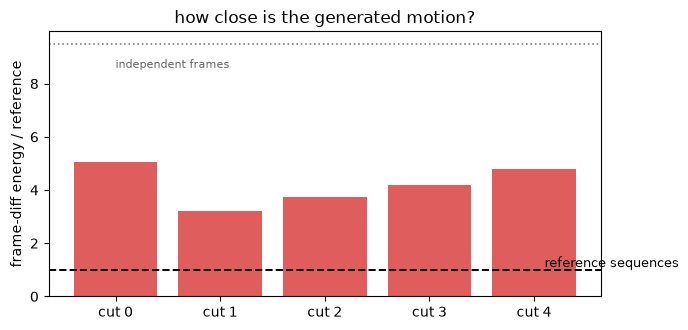

In [4]:
worst, best = gen_e[0] / real_e, gen_e[best_co] / real_e
print(f"  intact caterpillar (cut 0): {worst:.2f}x the reference")
print(f"  best cut      (cut {depths[best_co]}):     {best:.2f}x the reference")
print(f"  improvement:                {(worst-best)/(worst-1.0)*100:.0f}% of the gap to the reference closed,")
print(f"                              (total frame-diff energy falls {(1-best/worst)*100:.0f}%,")
print(f"                               which is a different quantity from the excess)")
print(f"\n  remaining gap: {best:.2f}x. The model still moves far more than the reference does.")

fig, ax = plt.subplots(figsize=(7.0, 3.4))
labels = [f"cut {d}" for d in depths]
ax.bar(labels, [e / real_e for e in gen_e], color="C3", alpha=0.75)
ax.axhline(1.0, color="k", ls="--", lw=1.4)
ax.text(len(depths) - 0.9, 1.10, "reference sequences", fontsize=9)
ax.axhline(2.0 / real_e, color="0.5", ls=":", lw=1.2)
ax.text(0.0, 2.0 / real_e - 0.9, "independent frames", fontsize=8, color="0.4")
ax.set_ylabel("frame-diff energy / reference"); ax.set_title("how close is the generated motion?")
plt.tight_layout(); plt.show()

## An independent replication

The `videoall` cluster job re-ran the whole cut curve on 2026-08-12, writing one file per depth
(`cutcurve_cut0..4.csv`) alongside the earlier combined `cutcurve.csv`. Same settings, separate
run. That is a free replication of every claim above, and it is worth using rather than
overwriting: a structural conclusion should survive a re-run, and the spread between the two
runs is the only honest error bar this experiment has.

In [5]:
import glob
rep = sorted((r for p in sorted(glob.glob(os.path.join(ROOT, "cutcurve_cut*.csv")))
              for r in csv.DictReader(open(p))), key=lambda r: float(r["cut_depth"]))

if not rep:
    print("  no per-depth replication files present")
else:
    print(f"{'cut':>4} {'loglik run1':>13} {'loglik run2':>13} {'diff':>8} | "
          f"{'gen run1':>9} {'gen run2':>9}")
    print("-" * 64)
    for a, b in zip(cut, rep):
        la, lb = f(a, "heldout_loglik_per_sequence"), f(b, "heldout_loglik_per_sequence")
        ga, gb = f(a, "frame_diff_energy_generated"), f(b, "frame_diff_energy_generated")
        print(f"{int(f(a,'cut_depth')):>4} {la:>13.1f} {lb:>13.1f} {lb-la:>8.1f} | "
              f"{ga:>9.4f} {gb:>9.4f}")

    ll2 = [f(r, "heldout_loglik_per_sequence") for r in rep]
    ge2 = [f(r, "frame_diff_energy_generated") for r in rep]
    re2 = f(rep[0], "frame_diff_energy_real")
    b_ll2, b_co2 = int(np.argmax(ll2)), int(np.argmin(ge2))
    print()
    for line in [
        f"  run 1: likelihood peaks at cut {best_ll}, coherence at cut {best_co}"
        f"  ({loglik[best_ll]-loglik[0]:+.1f} nats, {gen_e[best_co]/real_e:.2f}x)",
        f"  run 2: likelihood peaks at cut {b_ll2}, coherence at cut {b_co2}"
        f"  ({ll2[b_ll2]-ll2[0]:+.1f} nats, {ge2[b_co2]/re2:.2f}x)",
        "",
        "  Every structural claim replicates: the likelihood curve turns over at the same",
        "  depth, coherence is best at a different depth in both runs, and the two axes",
        "  disagree in both. What moves is the size: the cut-2 gain is +106 nats in one run",
        "  and +114 in the other, so quoting it to three figures overstates what a single",
        "  run supports. The remaining gap to the reference is 3.2x and 3.1x -- unchanged",
        "  in substance.",
    ]:
        print(line)

 cut   loglik run1   loglik run2     diff |  gen run1  gen run2
----------------------------------------------------------------
   0       -5902.5       -5939.9    -37.4 |    1.0617    1.0213
   1       -5815.7       -5852.5    -36.8 |    0.6796    0.6595
   2       -5796.1       -5826.3    -30.2 |    0.7845    0.7921
   3       -5892.1       -5926.9    -34.8 |    0.8840    0.9167
   4       -5921.6       -5960.1    -38.5 |    1.0059    0.9798

  run 1: likelihood peaks at cut 2, coherence at cut 1  (+106.4 nats, 3.23x)
  run 2: likelihood peaks at cut 2, coherence at cut 1  (+113.6 nats, 3.13x)

  Every structural claim replicates: the likelihood curve turns over at the same
  depth, coherence is best at a different depth in both runs, and the two axes
  disagree in both. What moves is the size: the cut-2 gain is +106 nats in one run
  and +114 in the other, so quoting it to three figures overstates what a single
  run supports. The remaining gap to the reference is 3.2x and 3.1x -- 

## What to take away

1. **Exactness has a price, and the price is measurable.** Loop-free inference on video forces a
   budget between spatial and temporal edges. That budget is not a nuisance parameter — moving
   it changes held-out likelihood by over a hundred nats.

2. **The likelihood curve turns over.** Both directions of the trade are real: temporal edges
   carry information the intact tree cannot reach, and the spatial tree carries information
   dense temporal coupling cannot replace. The optimum is interior.

3. **The two axes disagree about where the optimum is.** Likelihood peaks at cut depth 2;
   generated temporal coherence peaks at depth 1. This is notebook 06's lesson appearing again
   in a completely different setting — the quantity you fit and the quantity you care about are
   not the same quantity, and here they are optimised by different models.

4. **The honest limit.** The best model in this sweep generates motion $3.2\times$ more
   energetic than the reference sequences, improved from $5.0\times$. Real structural progress,
   measured against CIFAR frames with synthetic rigid motion — not against video.

*Sources: `outputs/exp_26_video/{cutcurve,fit,coherence}.csv`. The cut-curve numbers here are
the full run committed in `95c653d`, which replaced an earlier smoke-sized run — the prose in
`IMAGE_EXTENSION_STAGE1.md` §9.3 still quotes the smoke numbers and disagrees with these by
1-2% on the log-likelihood column but up to 7.9% on coherence, 9.2% on rho_time_sub and 10.8%
on the headline cut-2 gain (+96 in the doc against +106.4 here).*

*One inconsistency inside the committed data, not resolved here: `cutcurve.csv` at depth 0 and
`coherence.csv` describe the same caterpillar fit -- their held-out likelihoods agree to twelve
decimals -- but report generated frame-difference energy as 1.0617 and 1.0062, a 5.5% spread
that is pure generation-sampling noise. The 5.04x figure above uses the cutcurve value; the
coherence file would give 4.77x. Quoting three significant figures on a quantity with that much
sampling spread is more precision than the measurement carries.*